# MRS Data Augmentation Demo

This notebook demonstrates MRS augmentations using **Augmentrum** modules.

**Structure:**
1. Load COWS data (metabolite, MM, water references, simulated if available)
2. Process with Augmentrum pipeline
3. Plot all signals side-by-side
4. Apply augmentations step-by-step with visualizations


## Configuration

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import convolve, hilbert
from scipy.interpolate import BSpline
from pathlib import Path

# Augmentrum
from augmentrum.augmentation import (
    GaussianNoise, LineBroadening, PhaseShift, FrequencyShift,
    BaselineAugmentation, Apodization, EddyCurrent, ResidualWater,
    SpuriousEchoes, ArtificialPeaks, AmplitudeScaling
)
from augmentrum.core import NIfTI_MRS_Plus, AugmentationPipeline
from augmentrum.sampling.coil_average_sampler import CoilAverageSampler
from augmentrum.processing.nifti_raw_processor import NIfTI_RawProcessor
from augmentrum.dataset.cows import COWSDataModule
from fsl_mrs.core.nifti_mrs import gen_nifti_mrs

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

/Users/me/mamba/envs/mine/lib/python3.10/site-packages/hlsvdpropy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Data paths
DATA_DIR = '../data/openneuro_ds006812/'
SIMULATED_PATH = None  # Set to path if you have simulated data .mat file

# Reference PPM
REF_PPM = 4.7

## Helper Functions

In [3]:
def plot_individual(fid_list, sw_hz, sf_mhz, num_plots, ref_water_ppm, titles):
    """
    Plot any spectrum that contains these parameters.
    Same function as in augment_mrs.ipynb
    """
    # Normalize inputs
    fid_list = [np.asarray(f).squeeze() for f in fid_list]
    sw_hz    = np.asarray(sw_hz, dtype=float).ravel()
    sf_mhz   = np.asarray(sf_mhz, dtype=float).ravel()

    if num_plots is None:
        num_plots = len(fid_list)

    # Basic sanity checks
    if not (len(fid_list) == len(sw_hz) == len(sf_mhz)):
        raise ValueError("fid_list, sw_hz, and sf_mhz must have the same length")
    if num_plots != len(fid_list):
        raise ValueError("num_plots must equal len(fid_list) (or omit num_plots)")

    # Create subplots (ensure axs is always iterable)
    fig, axs = plt.subplots(num_plots, 1, figsize=(10, 2.6*num_plots), sharex=True)
    axs = np.atleast_1d(axs)

    for i in range(num_plots):
        fid = fid_list[i]
        n = fid.size
        dt = 1 / sw_hz[i]
        freq = np.fft.fftshift(np.fft.fftfreq(n, d=dt))  # Frequency (Hz)
        ppm = ref_water_ppm - freq / sf_mhz[i]          # ppm axis
        spec = np.fft.fftshift(np.fft.ifft(fid))         # Spectrum

        ax = axs[i]
        ax.plot(ppm, np.real(spec), lw=1)
        ax.invert_xaxis()             # high ppm on left
        ax.set_xlim(6, 0)
        ax.grid(alpha=0.3)
        ax.set_ylabel("Amplitude")

        title_str = f"Spectrum {i+1}" if not titles else titles[i]
        ax.set_title(title_str)

    axs[-1].set_xlabel("Chemical Shift (ppm)")
    fig.tight_layout()
    plt.show()
    return fig, axs

def fid_to_nifti_plus(fid_data, sw_hz, sf_mhz):
    """Convert FID to NIfTI_MRS_Plus for augmentation modules."""
    fid_data = np.asarray(fid_data).squeeze()
    nifti = gen_nifti_mrs(
        fid_data.reshape(1, 1, 1, -1), 
        dwelltime=1.0/sw_hz, 
        spec_freq=sf_mhz
    )
    return NIfTI_MRS_Plus([nifti], backend='nifti_list', volatile=True)

## 1. Load COWS Data

Load metabolite, macromolecule (MM), water references, and optional simulated data.


In [4]:
# Load COWS data
loader = COWSDataModule(data_dir=DATA_DIR, location='PARIETAL', water_sup='VAPOR')
data, water, mm, mm_water, names = loader.load_twix()

print(f"\n✓ Loaded {len(data)} subjects")
if len(data) > 0:
    print(f"  - Metabolite shape: {data[0].shape}")
    print(f"  - MM shape: {mm[0].shape if mm else 'N/A'}")
    print(f"  - Water shape: {water[0].shape if water else 'N/A'}")

# Load simulated data if available
fid_simulated = None
sw_simulated = None
sf_simulated = None
if SIMULATED_PATH is not None and Path(SIMULATED_PATH).exists():
    try:
        mat_sim = loadmat(SIMULATED_PATH, squeeze_me=True, struct_as_record=False)
        exptDat = mat_sim['exptDat']
        fid_simulated = np.array(exptDat.fid).squeeze()
        sw_simulated = float(exptDat.sw_h)
        sf_simulated = float(exptDat.sf)
        print(f"✓ Loaded simulated data: {fid_simulated.shape}")
    except Exception as e:
        print(f"✗ Could not load simulated data: {e}")
else:
    print("\n⚠ No simulated data path provided (set SIMULATED_PATH)")

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

...

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]


✓ Loaded 10 subjects
  - Metabolite shape: (1, 1, 1, 4096, 32, 32)
  - MM shape: (1, 1, 1, 4096, 32, 32)
  - Water shape: (1, 1, 1, 4096, 32)

⚠ No simulated data path provided (set SIMULATED_PATH)


## 2. Process Data with Augmentrum

Process first subject with NIfTI_RawProcessor (coil combination using fsl-mrs method).


In [5]:
# Wrap in NIfTI_MRS_Plus
data_plus = NIfTI_MRS_Plus([data[0]], backend='nifti_list')
water_plus = NIfTI_MRS_Plus([water[0]], backend='nifti_list') if water else None
mm_plus = NIfTI_MRS_Plus([mm[0]], backend='nifti_list') if mm else None
mm_water_plus = NIfTI_MRS_Plus([mm_water[0]], backend='nifti_list') if mm_water else None

# Create pipeline
processor = NIfTI_RawProcessor(coil_method='fsl-mrs', conj=False, remove_water=True)  # note: remove water is slow
pipeline = AugmentationPipeline([processor])

# Process each
print("Processing metabolite data...")
processed_metab, processed_water = pipeline(data_plus, water_plus)
fid_metab = processed_metab[0][:].squeeze()
sw_metab = 1.0 / processed_metab[0].dwelltime
sf_metab = processed_metab[0].spectrometer_frequency[0]

fid_water_metab = processed_water[0][:].squeeze() if processed_water else None
sw_water_metab = 1.0 / processed_water[0].dwelltime if processed_water else None
sf_water_metab = processed_water[0].spectrometer_frequency[0] if processed_water else None

if mm_plus:
    print("Processing MM data...")
    processed_mm, processed_mm_water = pipeline(mm_plus, mm_water_plus)
    fid_mm = processed_mm[0][:].squeeze()
    sw_mm = 1.0 / processed_mm[0].dwelltime
    sf_mm = processed_mm[0].spectrometer_frequency[0]

    fid_water_mm = processed_mm_water[0][:].squeeze() if processed_mm_water else None
    sw_water_mm = 1.0 / processed_mm_water[0].dwelltime if processed_mm_water else None
    sf_water_mm = processed_mm_water[0].spectrometer_frequency[0] if processed_mm_water else None
else:
    fid_mm = None
    sw_mm = None
    sf_mm = None
    fid_water_mm = None
    sw_water_mm = None
    sf_water_mm = None

print(f"\n✓ Processed metabolite FID shape: {fid_metab.shape}")
print(f"  SW: {sw_metab:.1f} Hz, SF: {sf_metab:.3f} MHz")
if fid_mm is not None:
    print(f"✓ Processed MM FID shape: {fid_mm.shape}")


Processing metabolite data...
Processing MM data...

✓ Processed metabolite FID shape: (4096,)
  SW: 8000.0 Hz, SF: 123.259 MHz
✓ Processed MM FID shape: (4096,)


## 3. Plot All Signals

Plot metabolite, simulated (if available), MM, and water references side by side.


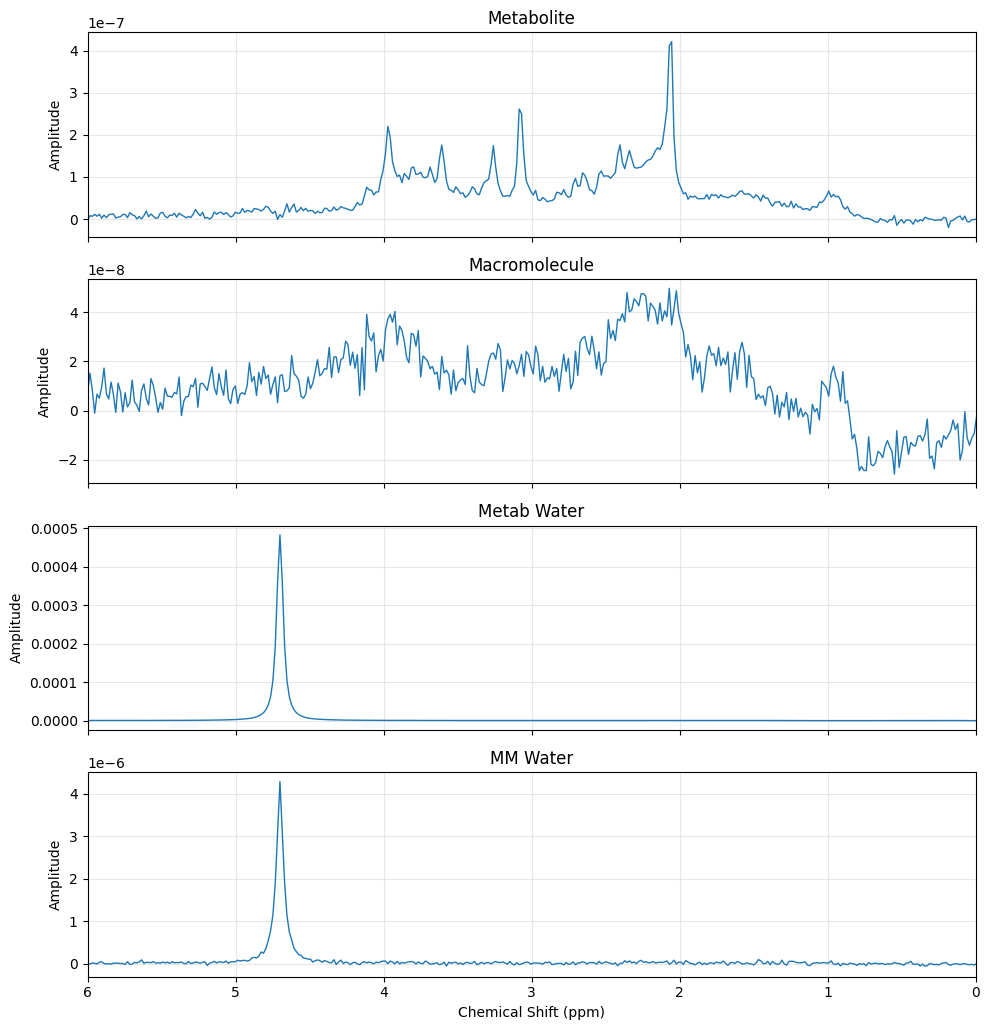

In [6]:
# Prepare lists for plotting
plot_fids = []
plot_sw = []
plot_sf = []
plot_titles = []

# Metabolite (always available)
plot_fids.append(fid_metab)
plot_sw.append(sw_metab)
plot_sf.append(sf_metab)
plot_titles.append("Metabolite")

# Simulated (if available)
if fid_simulated is not None:
    plot_fids.append(fid_simulated)
    plot_sw.append(sw_simulated)
    plot_sf.append(sf_simulated)
    plot_titles.append("Simulated")

# MM (if available)
if fid_mm is not None:
    plot_fids.append(fid_mm)
    plot_sw.append(sw_mm)
    plot_sf.append(sf_mm)
    plot_titles.append("Macromolecule")

# Water references (if available)
if fid_water_metab is not None:
    plot_fids.append(fid_water_metab)
    plot_sw.append(sw_water_metab)
    plot_sf.append(sf_water_metab)
    plot_titles.append("Metab Water")

if fid_water_mm is not None:
    plot_fids.append(fid_water_mm)
    plot_sw.append(sw_water_mm)
    plot_sf.append(sf_water_mm)
    plot_titles.append("MM Water")

# Plot all
fig, axs = plot_individual(
    fid_list=plot_fids,
    sw_hz=plot_sw,
    sf_mhz=plot_sf,
    num_plots=len(plot_fids),
    ref_water_ppm=REF_PPM,
    titles=plot_titles
)


## 4. Select FID for Augmentation Demos

Choose which FID to use for augmentation demonstrations.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔧 SELECT WHICH DATA TO USE FOR AUGMENTATIONS
# ══════════════════════════════════════════════════════════════════════════════
USE_SIMULATED = False  # Set to True to use simulated data
USE_MM = False         # Set to True to use macromolecule data
# ══════════════════════════════════════════════════════════════════════════════

# Select data (use NIfTI_MRS_Plus directly, only convert simulated data)
if USE_SIMULATED and fid_simulated is not None:
    # Simulated data needs conversion
    fid = fid_simulated.copy()
    sw = sw_simulated
    sf = sf_simulated
    nifti_plus = fid_to_nifti_plus(fid, sw, sf)
    print('✅ Using SIMULATED data for augmentations')
elif USE_MM and fid_mm is not None:
    # Use processed MM NIfTI_MRS_Plus directly
    nifti_plus = processed_mm
    fid = fid_mm.copy()  # For plotting original
    sw = sw_mm
    sf = sf_mm
    print('✅ Using MACROMOLECULE data for augmentations')
else:
    # Use processed metabolite NIfTI_MRS_Plus directly
    nifti_plus = processed_metab
    fid = fid_metab.copy()  # For plotting original
    sw = sw_metab
    sf = sf_metab
    print('✅ Using METABOLITE data for augmentations')

print(f'FID shape: {fid.shape}, SW: {sw:.1f} Hz, SF: {sf:.3f} MHz')
print(f'NIfTI_MRS_Plus: {nifti_plus.shape}, backend: {nifti_plus.backend.value}')

✅ Using METABOLITE data for augmentations
FID shape: (4096,), SW: 8000.0 Hz, SF: 123.259 MHz
NIfTI_MRS_Plus: (1, 1, 1, 1, 4096), backend: nifti_list


## 5. Augmentation Demonstrations

All augmentations use the same plotting style as augment_mrs.ipynb with `plot_individual` function.

**Ordering matches augment_mrs.ipynb exactly:**
1. Line broadening (Lorentzian-Only, Gaussian-Only, and Voigt Broadening)
2. Apodization (Truncation and Weighted Exponential)
3. Zerofilling (padding)
4. Random Walk Baseline and Residual Water
5. B-Spline Baseline
6. Amplitude Scaling (Only for Simulated spectra using basis functions)
7. Zero-Order Phase
8. First-Order Phase
9. Frequency Shift
10. Eddy Currents
11. Peak Contamination
12. Spurious Echoes
13. Combined Augmentations


## Line broadening (Lorentzian-Only, Gaussian-Only, and Voigt Broadening)


LINE BROADENING


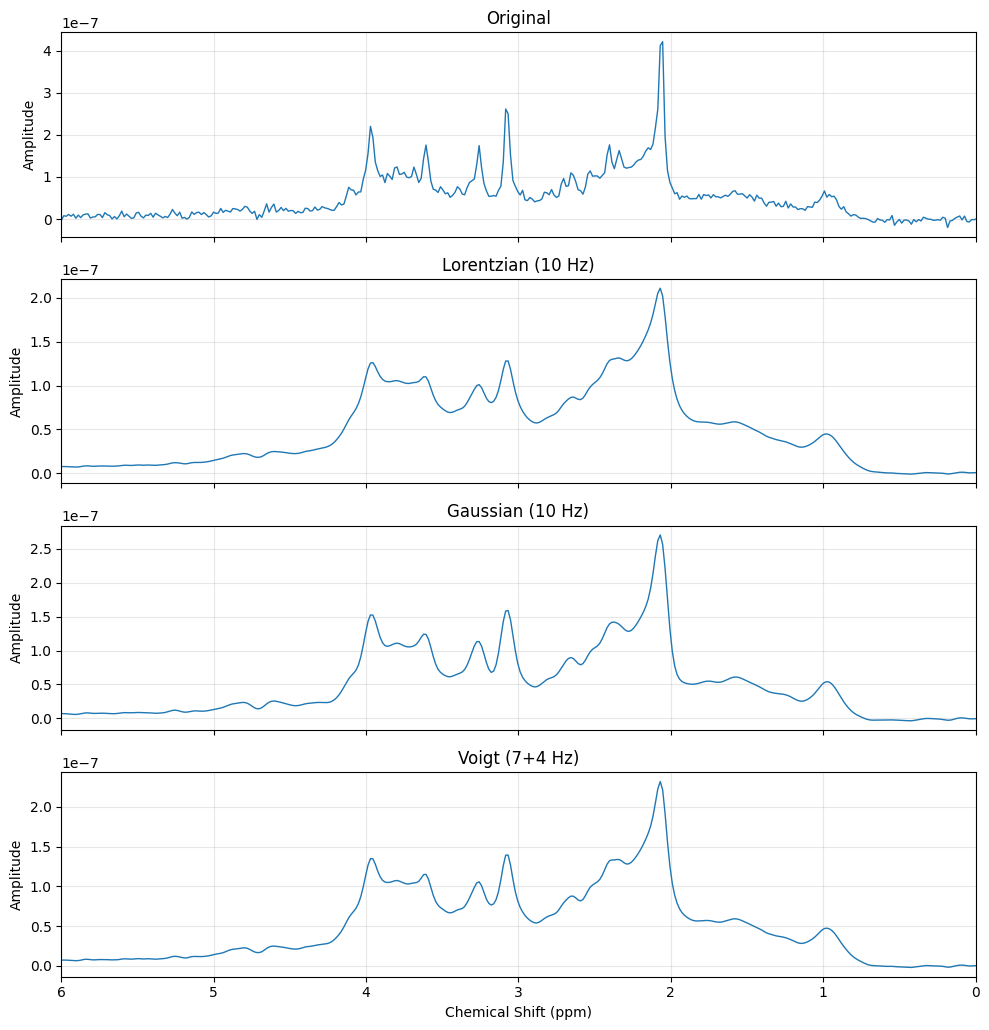

In [8]:
print("\n" + "="*80)
print("LINE BROADENING")
print("="*80)

# Lorentzian only
fid_lb_lor = LineBroadening(lb_hz=10.0, mode='lorentzian')(nifti_plus.copy(), None)[0][0][:].squeeze()

# Gaussian only
fid_lb_gau = LineBroadening(gb_hz=10.0, mode='gaussian')(nifti_plus.copy(), None)[0][0][:].squeeze()

# Voigt (combination)
fid_lb_voigt = LineBroadening(lb_hz=7.0, gb_hz=4.0, mode='voigt')(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_lb_lor, fid_lb_gau, fid_lb_voigt],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Lorentzian (10 Hz)", "Gaussian (10 Hz)", "Voigt (7+4 Hz)"]
)


### View Provenance

The NIfTI-MRS header extension contains provenance information about all operations applied.

**To view provenance:**
- `nifti_plus[0].hdr_ext` - Shows all metadata and processing history
- Look for the `ProcessingApplied` field to see the full chain of operations

In [9]:
print("="*80)
print("PROVENANCE EXAMPLE (with volatile=False)")
print("="*80)

# Create a non-volatile copy to demonstrate provenance
nifti_prov = nifti_plus.copy()
nifti_prov._volatile = False  # Enable provenance logging

# Apply augmentation
voigt_aug = LineBroadening(lb_hz=7.0, gb_hz=4.0, mode='voigt')
result_prov, _ = voigt_aug(nifti_prov, None)

print(result_prov[0].hdr_ext['ProcessingApplied'])

print("\n" + "="*80)
print("TIP: Each augmentation adds an entry to ProcessingApplied")
print("="*80)
print("This allows full traceability of all operations applied to the data.")
print("If volatile=False (default), all provenance is logged.")
print("If volatile=True, provenance logging is skipped for faster processing.")

PROVENANCE EXAMPLE (with volatile=False)
[{'Time': '2026-02-08T18:25:09.895', 'Program': 'FSL-MRS', 'Version': '2.1.20', 'Method': 'RF coil combination', 'Details': 'fsl_mrs.utils.preproc.nifti_mrs_proc.coilcombine, reference=, no_prewhiten=False.'}, {'Time': '2026-02-08T18:25:10.304', 'Program': 'FSL-MRS', 'Version': '2.1.20', 'Method': 'Frequency and phase correction', 'Details': 'fsl_mrs.utils.preproc.nifti_mrs_proc.align, dim=DIM_DYN, window=None, target=None, ppmlim=(0.2, 4.2), niter=2.'}, {'Time': '2026-02-08T18:25:10.317', 'Program': 'FSL-MRS', 'Version': '2.1.20', 'Method': 'Outlier removal', 'Details': 'fsl_mrs.utils.preproc.nifti_mrs_proc.remove_unlike, ppmlim=None, sdlimit=1.96, niter=2.'}, {'Time': '2026-02-08T18:25:10.317', 'Program': 'FSL-MRS', 'Version': '2.1.20', 'Method': 'Signal averaging', 'Details': 'fsl_mrs.utils.preproc.nifti_mrs_proc.average, dim=DIM_DYN.'}, {'Time': '2026-02-08T18:25:10.674', 'Program': 'Augmentrum', 'Version': '0.0.1', 'Method': 'Eddy current c

## Apodization (Truncation and Weighted Exponential)


APODIZATION (TRUNCATION AND WEIGHTED EXPONENTIAL)
Original Spectrum # of Points: 4096
Apodization by weighting exponential # of Points: 4096
Apodization by truncation # of Points: 2048
Calculated Lorentzian Broadening for Exponential Apod.: 5.0


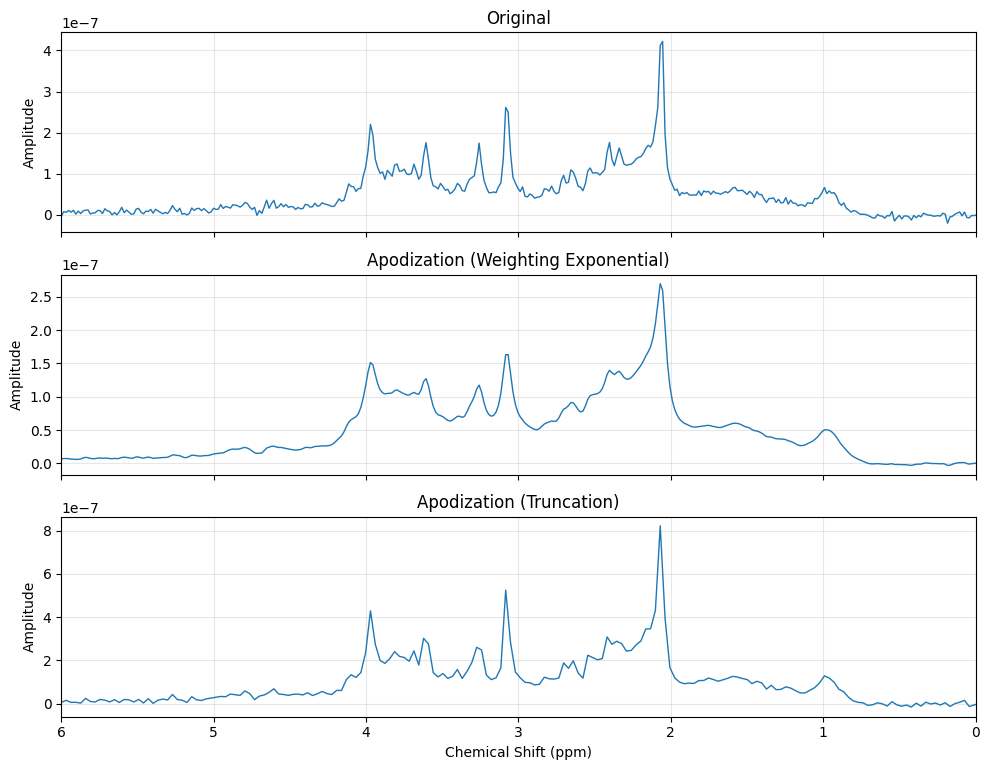

In [10]:
print("\n" + "="*80)
print("APODIZATION (TRUNCATION AND WEIGHTED EXPONENTIAL)")
print("="*80)

# Weighted Exponential Apodization
apod_exp = Apodization(mode='exponential', lb_hz=5.0)
fid_apod_exp = apod_exp(nifti_plus.copy(), None)[0][0][:].squeeze()

# Truncation Apodization (reduces number of points)
# Note: Truncation mode is currently not fully implemented in Apodization module
# Demonstrating with simple truncation
fid_apod_trunc = fid[:len(fid)//2]  # Truncate to half points (2048 -> 1024)
sw_trunc = sw
sf_trunc = sf

print(f"Original Spectrum # of Points: {len(fid)}")
print(f"Apodization by weighting exponential # of Points: {len(fid_apod_exp)}")
print(f"Apodization by truncation # of Points: {len(fid_apod_trunc)}")

# Calculate equivalent Lorentzian broadening for exponential apodization
print(f"Calculated Lorentzian Broadening for Exponential Apod.: {apod_exp.lb_hz}")

fig, axs = plot_individual(
    fid_list=[fid, fid_apod_exp, fid_apod_trunc],
    sw_hz=[sw, sw, sw_trunc],
    sf_mhz=[sf, sf, sf_trunc],
    num_plots=3,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Apodization (Weighting Exponential)", "Apodization (Truncation)"]
)


## Zerofilling (padding)

**Note:** Zerofilling is typically a preprocessing step. In NIfTI_RawProcessor, this is handled via the `truncate` parameter. Here we demonstrate the concept with simple zero-padding.



ZEROFILLING (PADDING)


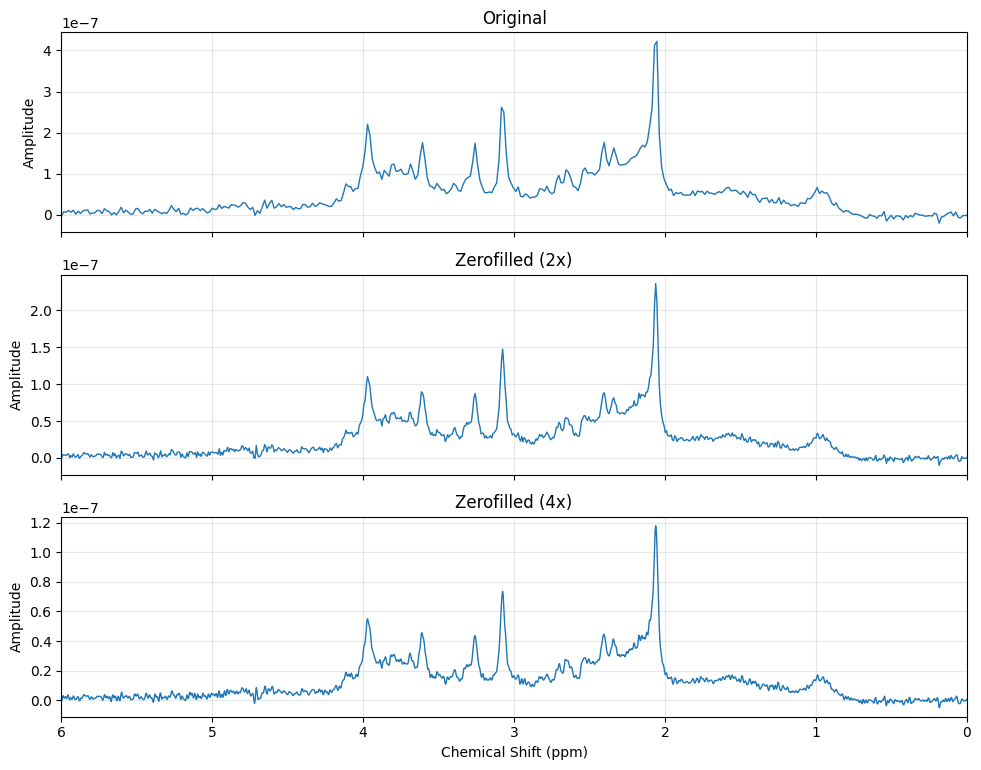


⚠️  Note: Zerofilling increases spectral resolution but does NOT add information.
   It's an interpolation in the frequency domain.


In [11]:
print("\n" + "="*80)
print("ZEROFILLING (PADDING)")
print("="*80)

# Demonstrate zero-padding concept
# Note: This changes the spectral resolution
fid_padded_2x = np.pad(fid, (0, len(fid)), mode='constant', constant_values=0)
sw_padded_2x = sw  # SW stays the same
sf_padded_2x = sf

fid_padded_4x = np.pad(fid, (0, 3*len(fid)), mode='constant', constant_values=0)
sw_padded_4x = sw
sf_padded_4x = sf

fig, axs = plot_individual(
    fid_list=[fid, fid_padded_2x, fid_padded_4x],
    sw_hz=[sw, sw_padded_2x, sw_padded_4x],
    sf_mhz=[sf, sf_padded_2x, sf_padded_4x],
    num_plots=3,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Zerofilled (2x)", "Zerofilled (4x)"]
)

print("\n⚠️  Note: Zerofilling increases spectral resolution but does NOT add information.")
print("   It's an interpolation in the frequency domain.")


## Random Walk Baseline and Residual Water


### Random Walk Baseline (with Hilbert transform)

The baseline augmentation in Augmentrum uses a random walk approach. The default includes Hilbert transform for realistic complex baseline.



RANDOM WALK BASELINE (WITH HILBERT TRANSFORM)


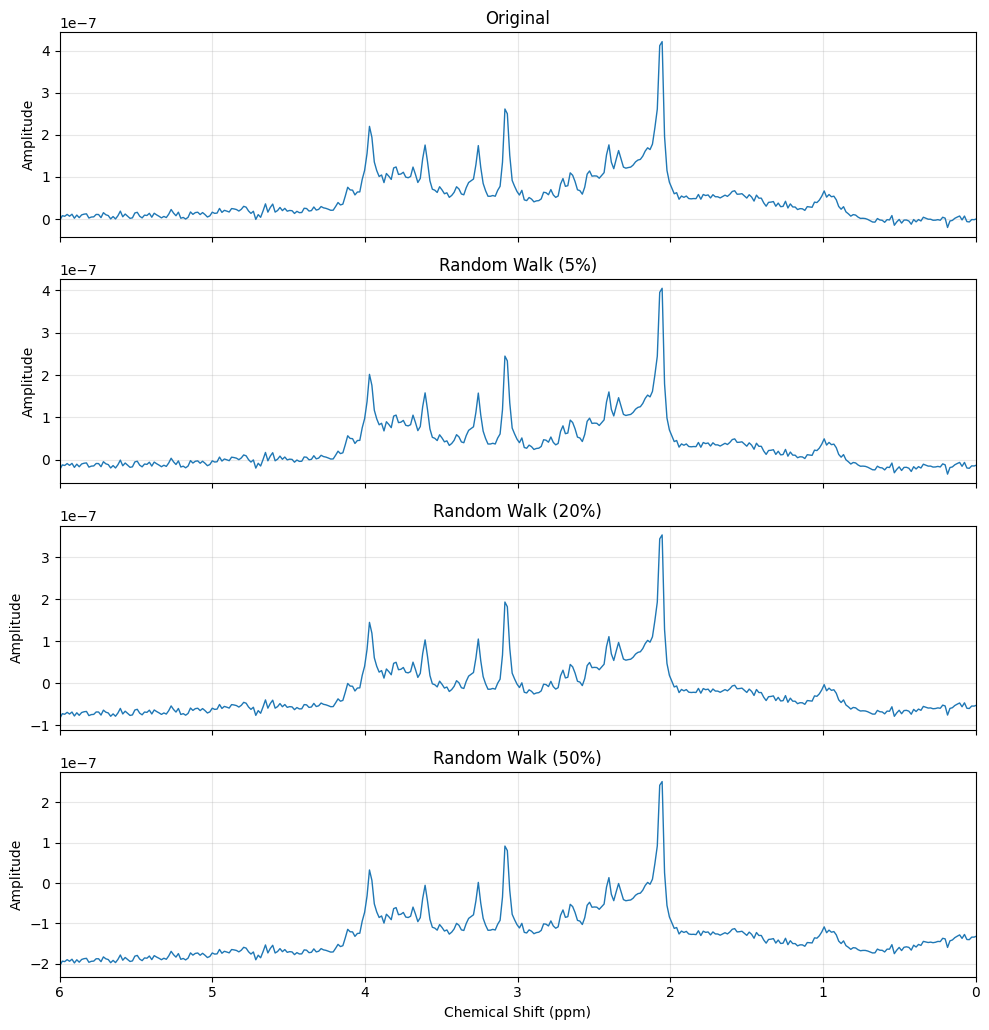

In [12]:
print("\n" + "="*80)
print("RANDOM WALK BASELINE (WITH HILBERT TRANSFORM)")
print("="*80)

# Different levels of random walk baseline
# TODO: adjust scaling better, also for poly...
fid_rw_low = BaselineAugmentation(mode='random_walk', baseline_frac=0.05, seed=42)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_rw_med = BaselineAugmentation(mode='random_walk', baseline_frac=0.2, seed=42)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_rw_high = BaselineAugmentation(mode='random_walk', baseline_frac=0.5, seed=42)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_rw_low, fid_rw_med, fid_rw_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Random Walk (5%)", "Random Walk (20%)", "Random Walk (50%)"]
)


### Residual Water

Add residual water peaks that weren't fully suppressed.



RESIDUAL WATER


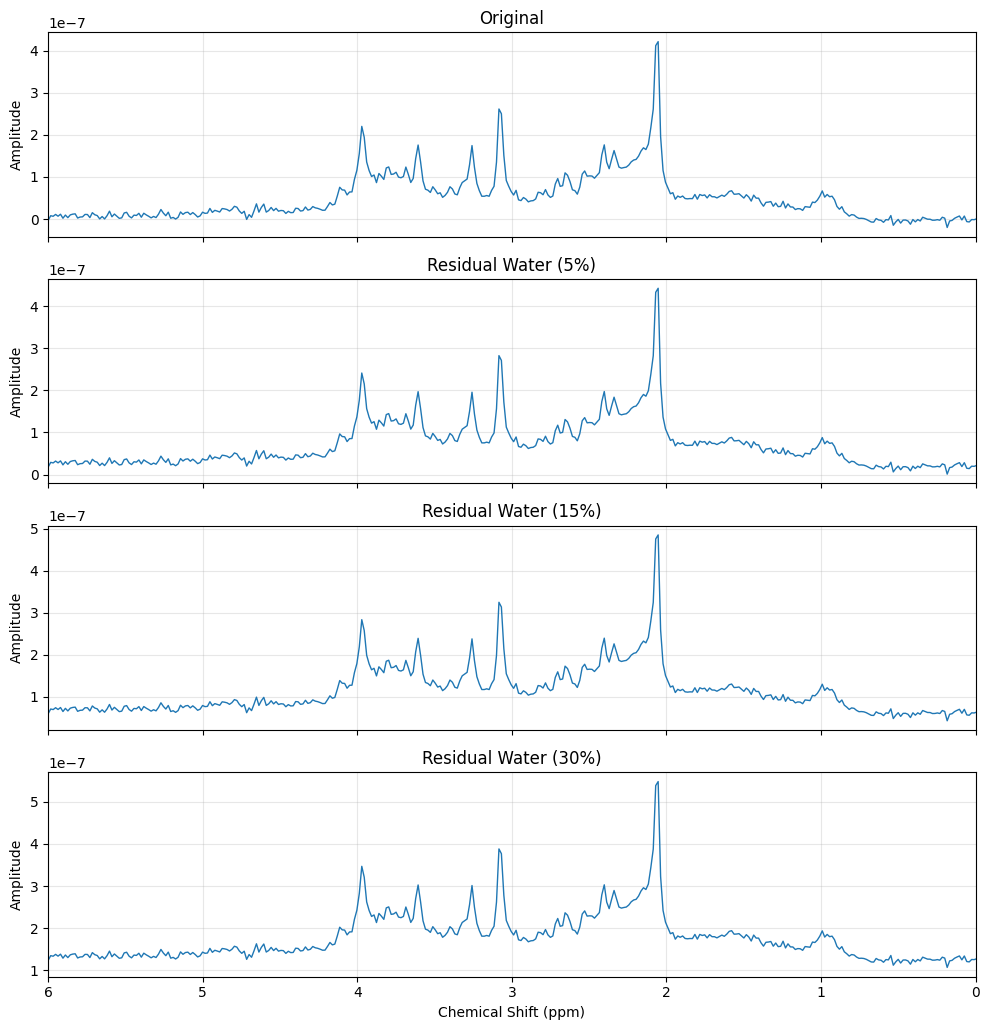

In [13]:
print("\n" + "="*80)
print("RESIDUAL WATER")
print("="*80)

# Different levels of residual water using tuple API
# TODO: find issue!
water_low = ResidualWater(
    center_ppm=4.7,
    peaks=((0.0, 0.20, 1.0), (0.12, 0.18, 0.4), (-0.15, 0.25, 0.3)),
    amplitude_scale=0.05
)
fid_water_low = water_low(nifti_plus.copy(), None)[0][0][:].squeeze()

water_med = ResidualWater(
    center_ppm=4.7,
    peaks=((0.0, 0.20, 1.0), (0.12, 0.18, 0.4), (-0.15, 0.25, 0.3)),
    amplitude_scale=0.15
)
fid_water_med = water_med(nifti_plus.copy(), None)[0][0][:].squeeze()

water_high = ResidualWater(
    center_ppm=4.7,
    peaks=((0.0, 0.20, 1.0), (0.12, 0.18, 0.4), (-0.15, 0.25, 0.3)),
    amplitude_scale=0.30
)
fid_water_high = water_high(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_water_low, fid_water_med, fid_water_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Residual Water (5%)", "Residual Water (15%)", "Residual Water (30%)"]
)


## B-Spline Baseline


B-SPLINE BASELINE


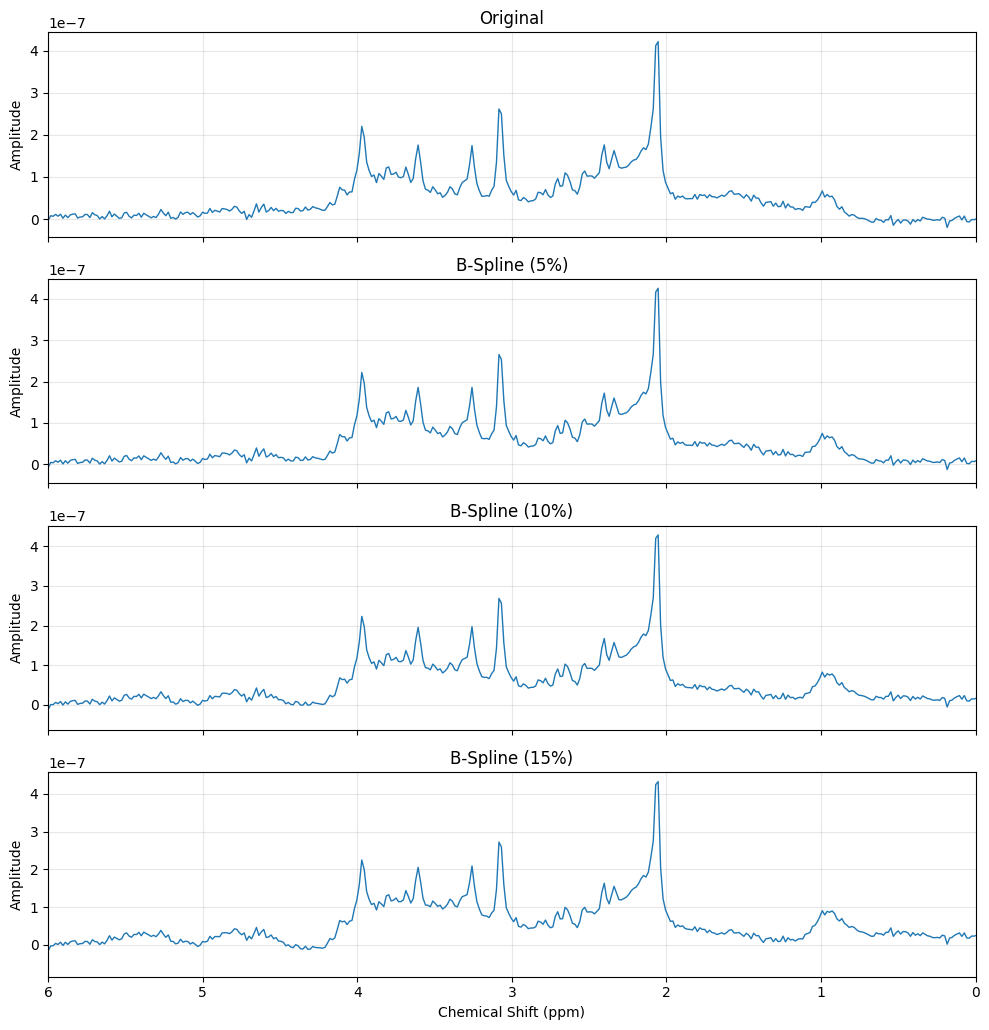

In [14]:
print("\n" + "="*80)
print("B-SPLINE BASELINE")
print("="*80)

# B-spline baseline with different amplitudes
fid_bspline_low = BaselineAugmentation(
    mode='bspline', baseline_frac=0.05, knots_per_ppm=12, ed_per_ppm=3.0, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fid_bspline_med = BaselineAugmentation(
    mode='bspline', baseline_frac=0.10, knots_per_ppm=12, ed_per_ppm=3.0, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fid_bspline_high = BaselineAugmentation(
    mode='bspline', baseline_frac=0.15, knots_per_ppm=12, ed_per_ppm=3.0, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_bspline_low, fid_bspline_med, fid_bspline_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "B-Spline (5%)", "B-Spline (10%)", "B-Spline (15%)"]
)


## Polynomial Baseline


POLYNOMIAL BASELINE


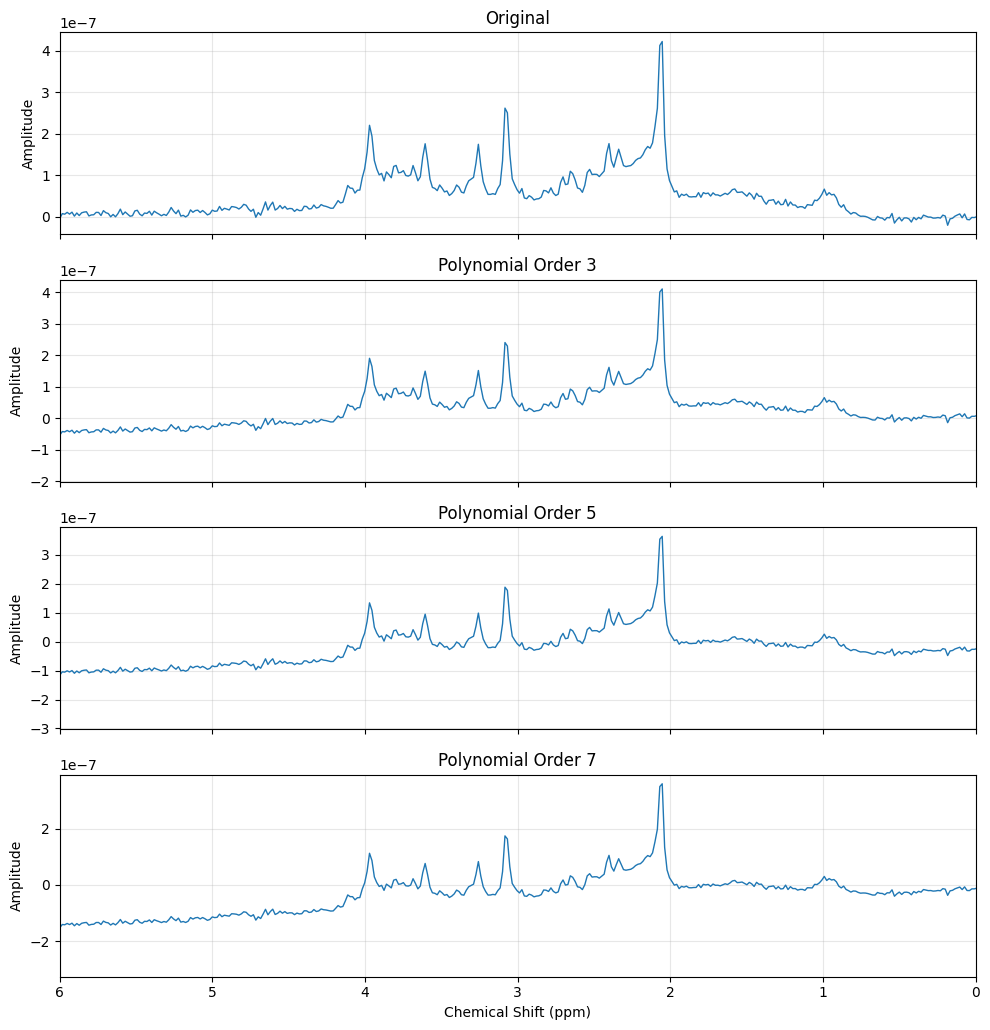


💡 Polynomial baseline:
   • Fitted to edge regions of spectrum
   • order: polynomial degree (3, 5, 7, etc.)
   • ppm_windows: can specify custom baseline regions


In [15]:
print("\n" + "="*80)
print("POLYNOMIAL BASELINE")
print("="*80)

# Polynomial baseline with different orders
fid_poly_low = BaselineAugmentation(
    mode='polynomial', baseline_frac=5, order=3, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fid_poly_med = BaselineAugmentation(
    mode='polynomial', baseline_frac=5, order=5, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fid_poly_high = BaselineAugmentation(
    mode='polynomial', baseline_frac=5, order=7, seed=42
)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_poly_low, fid_poly_med, fid_poly_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Polynomial Order 3", "Polynomial Order 5", "Polynomial Order 7"]
)

print("\n💡 Polynomial baseline:")
print("   • Fitted to edge regions of spectrum")
print("   • order: polynomial degree (3, 5, 7, etc.)")
print("   • ppm_windows: can specify custom baseline regions")



## Amplitude Scaling (Only for Simulated spectra using basis functions)

**Note:** Amplitude scaling is only applicable to simulated data where you have basis functions to scale individual metabolites. This cannot be cleanly applied to in-vivo data without first fitting to a basis set.

For demonstration purposes, we show simple global amplitude scaling:



AMPLITUDE SCALING


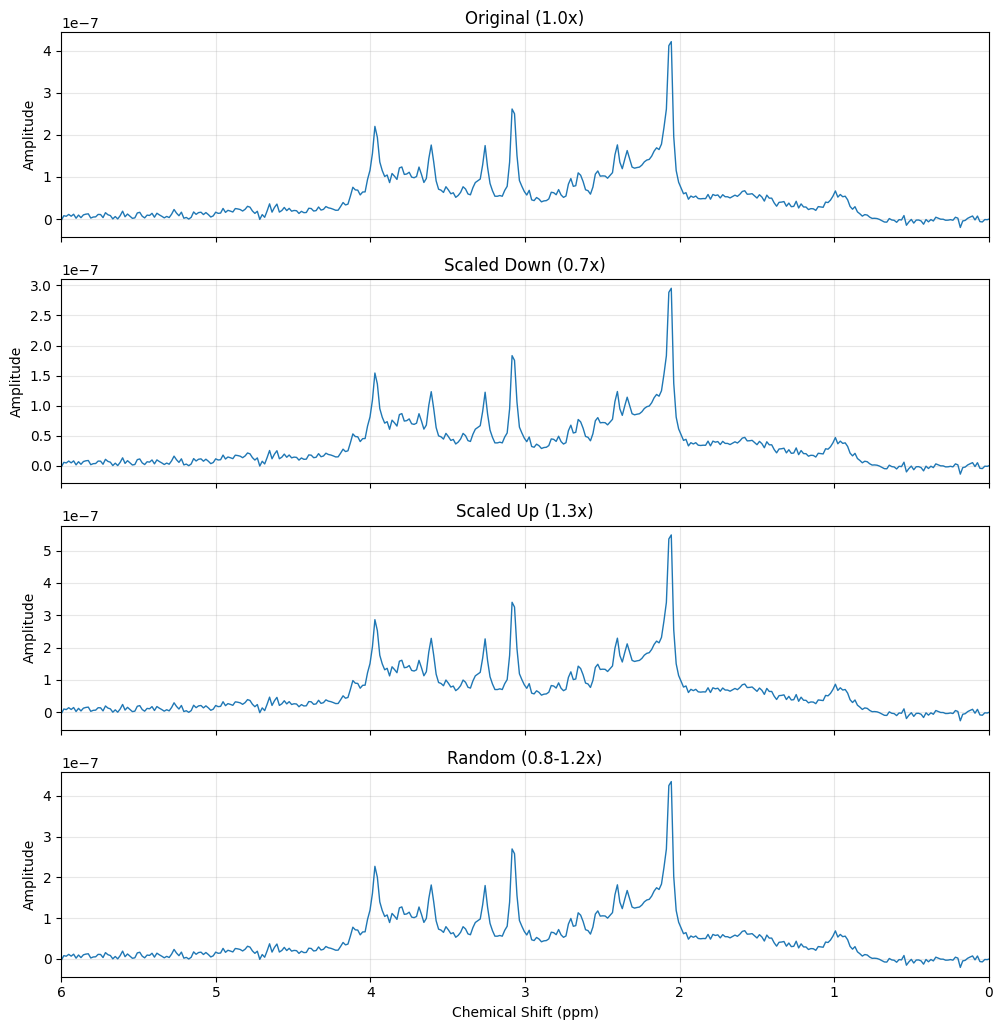


⚠️  Note: True amplitude scaling requires access to individual metabolite basis
   functions (e.g., for simulated data). This demo shows global scaling only.
   For metabolite-specific scaling:
   1. Fit in-vivo data to a basis set
   2. Scale individual metabolite components
   3. Reconstruct the FID


In [16]:
print("\n" + "="*80)
print("AMPLITUDE SCALING")
print("="*80)

# Fixed scaling factors
scaler_low = AmplitudeScaling(scale_factor=0.7)
fid_scale_low = scaler_low(nifti_plus.copy(), None)[0][0][:].squeeze()

scaler_high = AmplitudeScaling(scale_factor=1.3)
fid_scale_high = scaler_high(nifti_plus.copy(), None)[0][0][:].squeeze()

# Random scaling in range
scaler_random = AmplitudeScaling(scale_factor=(0.8, 1.2), distribution='uniform')
fid_scale_random = scaler_random(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_scale_low, fid_scale_high, fid_scale_random],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original (1.0x)", "Scaled Down (0.7x)", "Scaled Up (1.3x)", "Random (0.8-1.2x)"]
)

print("\n⚠️  Note: True amplitude scaling requires access to individual metabolite basis")
print("   functions (e.g., for simulated data). This demo shows global scaling only.")
print("   For metabolite-specific scaling:")
print("   1. Fit in-vivo data to a basis set")
print("   2. Scale individual metabolite components")
print("   3. Reconstruct the FID")



ZERO-ORDER PHASE


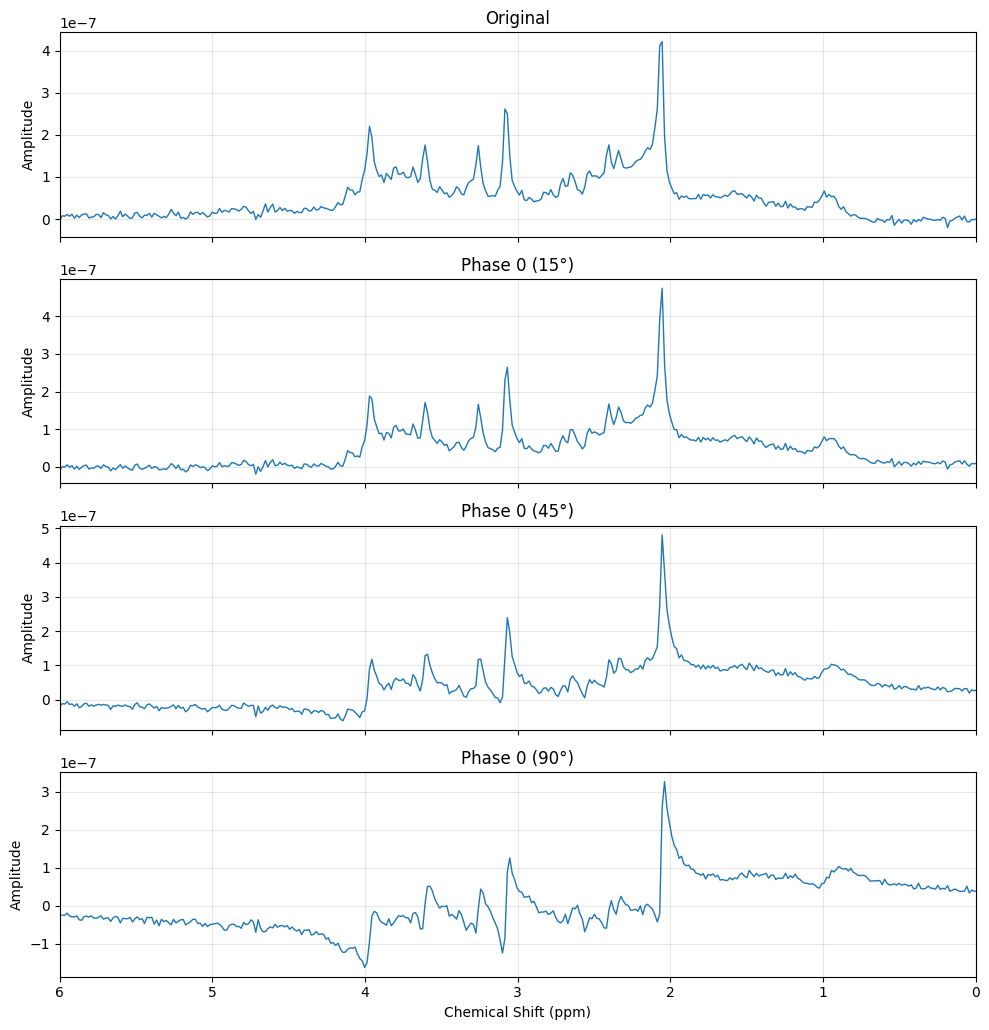

In [17]:
print("\n" + "="*80)
print("ZERO-ORDER PHASE")
print("="*80)

fid_phase0_low = PhaseShift(zero_order_deg=15.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_phase0_med = PhaseShift(zero_order_deg=45.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_phase0_high = PhaseShift(zero_order_deg=90.0)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_phase0_low, fid_phase0_med, fid_phase0_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Phase 0 (15°)", "Phase 0 (45°)", "Phase 0 (90°)"]
)


## First-Order Phase

First-order phase creates a frequency-dependent phase shift (linear ramp across spectrum). This creates asymmetric dispersive components that vary across the spectrum.



FIRST-ORDER PHASE


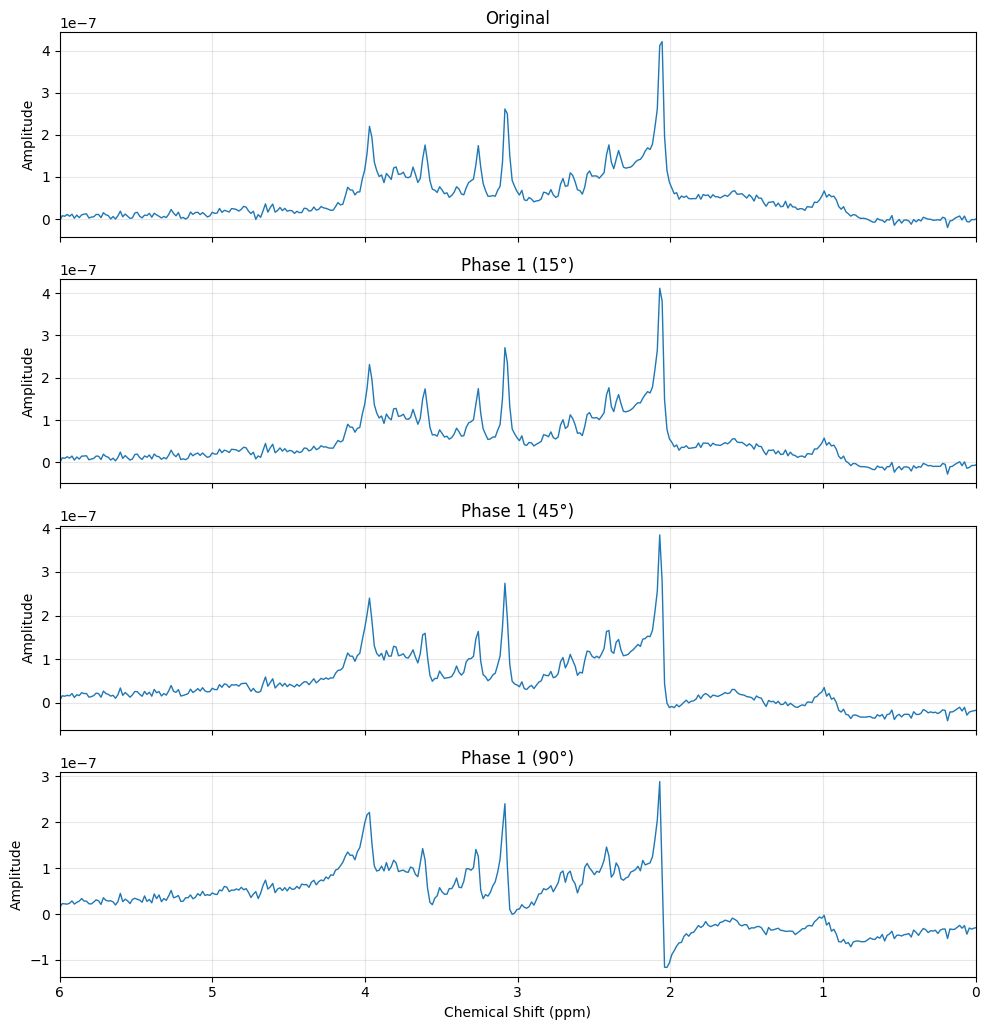

In [18]:
print("\n" + "="*80)
print("FIRST-ORDER PHASE")
print("="*80)

fid_phase1_low = PhaseShift(first_order_deg=15.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_phase1_med = PhaseShift(first_order_deg=45.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_phase1_high = PhaseShift(first_order_deg=90.0)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_phase1_low, fid_phase1_med, fid_phase1_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Phase 1 (15°)", "Phase 1 (45°)", "Phase 1 (90°)"]
)


## Frequency Shift


FREQUENCY SHIFT


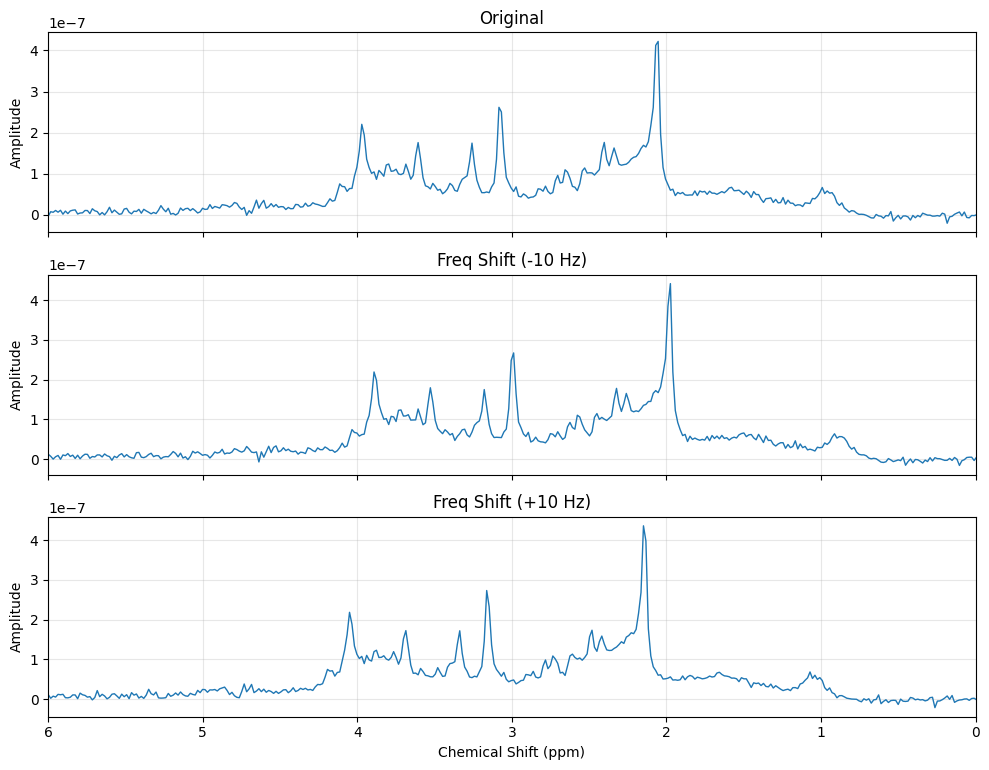

In [19]:
print("\n" + "="*80)
print("FREQUENCY SHIFT")
print("="*80)

fid_freq_neg = FrequencyShift(shift_hz=-10.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_freq_pos = FrequencyShift(shift_hz=10.0)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_freq_neg, fid_freq_pos],
    sw_hz=[sw, sw, sw],
    sf_mhz=[sf, sf, sf],
    num_plots=3,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Freq Shift (-10 Hz)", "Freq Shift (+10 Hz)"]
)


## Eddy Currents


EDDY CURRENTS


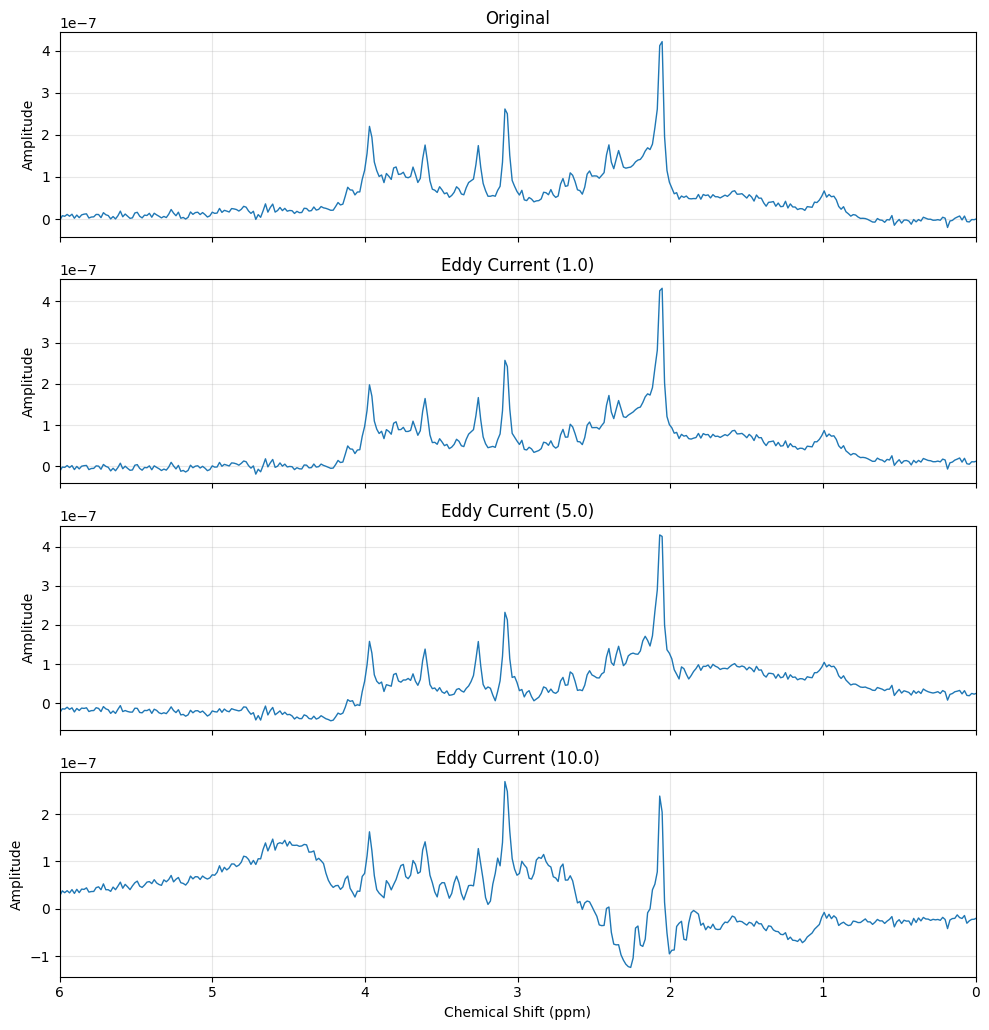

In [20]:
print("\n" + "="*80)
print("EDDY CURRENTS")
print("="*80)

# Synthetic eddy currents (different levels)
fid_eddy_low = EddyCurrent(mode='synthetic', strength=1.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_eddy_med = EddyCurrent(mode='synthetic', strength=5.0)(nifti_plus.copy(), None)[0][0][:].squeeze()
fid_eddy_high = EddyCurrent(mode='synthetic', strength=10.0)(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_eddy_low, fid_eddy_med, fid_eddy_high],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Eddy Current (1.0)", "Eddy Current (5.0)", "Eddy Current (10.0)"]
)


## Others to be revisited


### Peak contamination

Add spurious peaks at specific ppm locations with customizable amplitude, phase, and lineshape.



PEAK CONTAMINATION (ARTIFICIAL PEAKS)


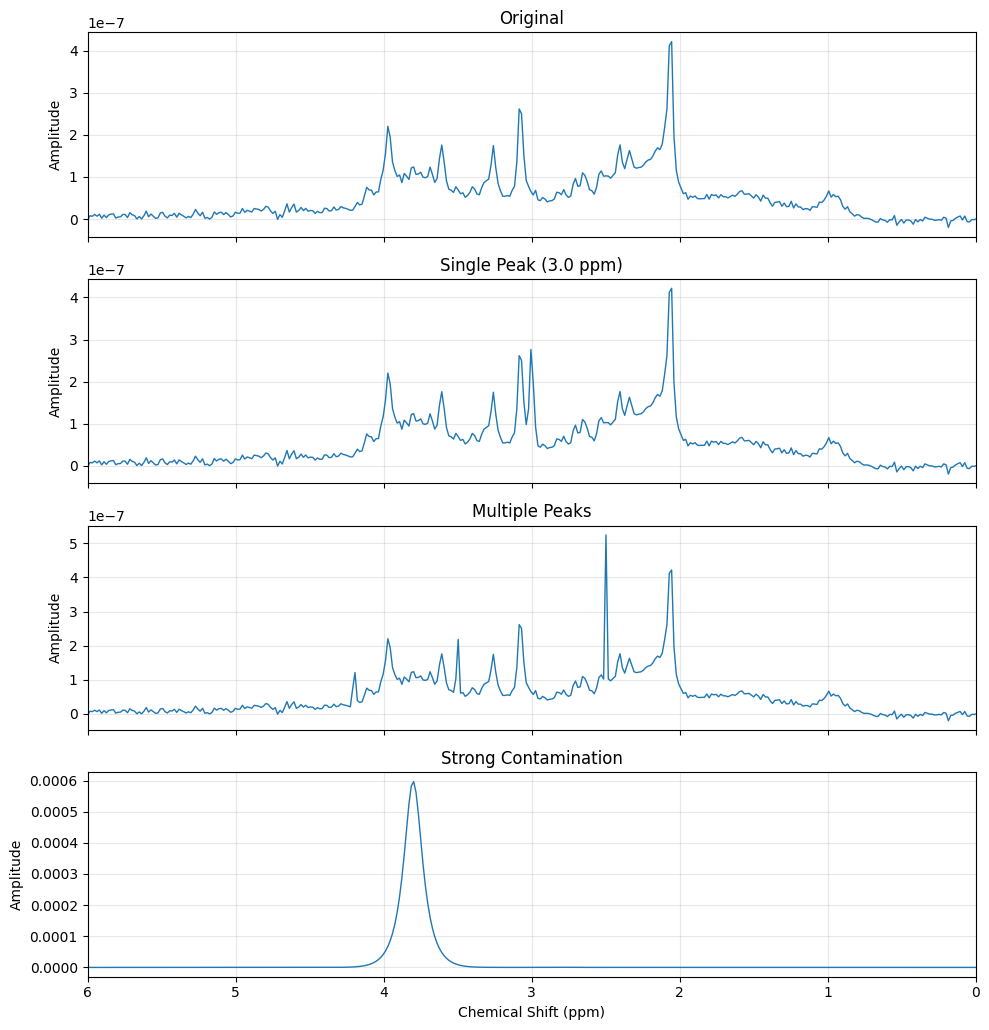

In [21]:
print("\n" + "="*80)
print("PEAK CONTAMINATION (ARTIFICIAL PEAKS)")
print("="*80)

# Single peak contamination
peaks_single = ArtificialPeaks(
    peaks=[
        {'ppm': 3.0, 'amplitude': 0.5, 'phase_deg': 0.0, 'lb_hz': 5.0, 'gb_hz': 5.0}
    ]
)
fid_peak_single = peaks_single(nifti_plus.copy(), None)[0][0][:].squeeze()

# Multiple peaks
peaks_multiple = ArtificialPeaks(
    peaks=[
        {'ppm': 2.5, 'amplitude': 1.0, 'phase_deg': 0.0, 'lb_hz': 4.0, 'gb_hz': 1.0},
        {'ppm': 3.5, 'amplitude': 0.5, 'phase_deg': 45.0, 'lb_hz': 3.0, 'gb_hz': 2.0},
        {'ppm': 4.2, 'amplitude': 0.25, 'phase_deg': -30.0, 'lb_hz': 6.0, 'gb_hz': 1.5}
    ]
)
fid_peak_multi = peaks_multiple(nifti_plus.copy(), None)[0][0][:].squeeze()

# Strong contamination
# TODO: fix phase issue!
peaks_strong = ArtificialPeaks(
    peaks=[
        {'ppm': 2.8, 'amplitude': 1.0, 'phase_deg': 0.0, 'lb_hz': 20.0, 'gb_hz': 50.0},
        {'ppm': 3.8, 'amplitude': 2000.0, 'phase_deg': 45.0, 'lb_hz': 20.0, 'gb_hz': 50.0}
    ]
)
fid_peak_strong = peaks_strong(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_peak_single, fid_peak_multi, fid_peak_strong],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Single Peak (3.0 ppm)", "Multiple Peaks", "Strong Contamination"]
)


### Spurious Echoes

Add spurious echo artifacts (ghosting effects).



SPURIOUS ECHOES


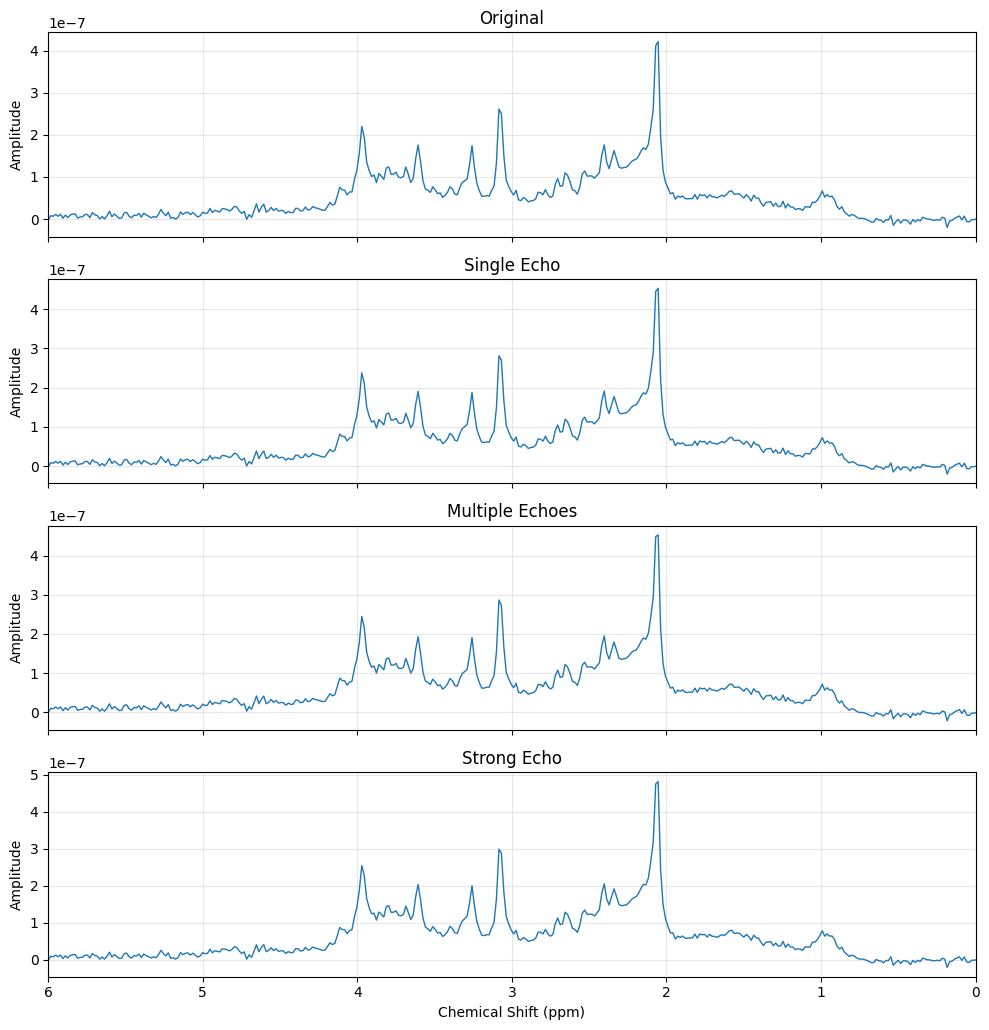

In [25]:
print("\n" + "="*80)
print("SPURIOUS ECHOES")
print("="*80)

# Single echo
# TODO: check and fix!
echo_single = SpuriousEchoes(
    echoes=[{'amplitude': 0.1, 'delay_pts': 200, 'phase_deg': 0.0, 'decay': 5.0}]
)
fid_echo_single = echo_single(nifti_plus.copy(), None)[0][0][:].squeeze()

# Multiple echoes
echo_multi = SpuriousEchoes(
    echoes=[
        {'amplitude': 0.08, 'delay_pts': 150, 'phase_deg': 0.0, 'decay': 3.0},
        {'amplitude': 0.05, 'delay_pts': 300, 'phase_deg': 45.0, 'decay': 6.0}
    ]
)
fid_echo_multi = echo_multi(nifti_plus.copy(), None)[0][0][:].squeeze()

# Strong echo
echo_strong = SpuriousEchoes(
    echoes=[{'amplitude': 0.2, 'delay_pts': 250, 'phase_deg': 0.0, 'decay': 8.0}]
)
fid_echo_strong = echo_strong(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_echo_single, fid_echo_multi, fid_echo_strong],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Single Echo", "Multiple Echoes", "Strong Echo"]
)


## Create the grid!

This section would show a comprehensive grid of augmentations. For now, we demonstrate with combined augmentations.


## Combined Augmentations


COMBINED AUGMENTATIONS


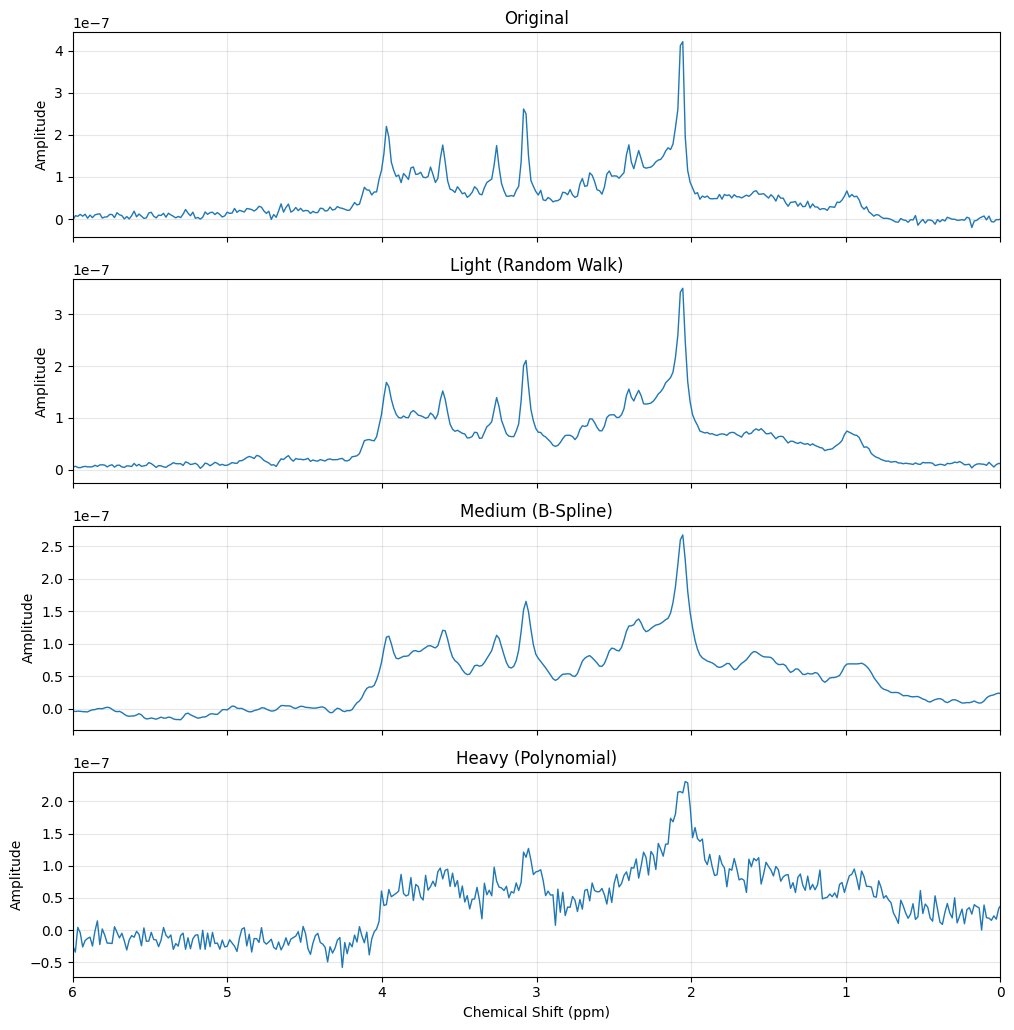

In [29]:
print("\n" + "="*80)
print("COMBINED AUGMENTATIONS")
print("="*80)

# Light augmentation (random walk baseline)
pipeline_light = AugmentationPipeline([
    GaussianNoise(sigma_frac=0.01),
    LineBroadening(lb_hz=2.0, gb_hz=1.0, mode='voigt'),
    PhaseShift(zero_order_deg=10.0, first_order_deg=5.0),
    BaselineAugmentation(mode='random_walk', baseline_frac=0.02)
])
fid_combined_light = pipeline_light(nifti_plus.copy(), None)[0][0][:].squeeze()

# Medium augmentation (B-spline baseline)
pipeline_medium = AugmentationPipeline([
    GaussianNoise(sigma_frac=0.03),
    LineBroadening(lb_hz=5.0, gb_hz=2.0, mode='voigt'),
    PhaseShift(zero_order_deg=30.0, first_order_deg=20.0),
    BaselineAugmentation(mode='bspline', baseline_frac=0.05)
])
fid_combined_medium = pipeline_medium(nifti_plus.copy(), None)[0][0][:].squeeze()

# Heavy augmentation (polynomial baseline)
pipeline_heavy = AugmentationPipeline([
    LineBroadening(lb_hz=10.0, gb_hz=5.0, mode='voigt'),
    PhaseShift(zero_order_deg=60.0, first_order_deg=45.0),
    BaselineAugmentation(mode='polynomial', baseline_frac=0.1, order=5),
    GaussianNoise(sigma_frac=0.02),
])
fid_combined_heavy = pipeline_heavy(nifti_plus.copy(), None)[0][0][:].squeeze()

fig, axs = plot_individual(
    fid_list=[fid, fid_combined_light, fid_combined_medium, fid_combined_heavy],
    sw_hz=[sw, sw, sw, sw],
    sf_mhz=[sf, sf, sf, sf],
    num_plots=4,
    ref_water_ppm=REF_PPM,
    titles=["Original", "Light (Random Walk)", "Medium (B-Spline)", "Heavy (Polynomial)"]
)